# PRODUCTION

In [53]:
from pathlib import Path
import pandas as pd
import re

pd.set_option("display.max_colwidth", None)  # Show full text in cells

def read_parquet(path_to_file):
    # Set your parquet file path here (works from project root or pdf_reader/)
    parquet_rel = Path(path_to_file)
    parquet_path = parquet_rel if parquet_rel.exists() else Path("..") / parquet_rel
    parquet_path = parquet_path.resolve()

    # Read parquet into a DataFrame ("unpack")
    df = pd.read_parquet(parquet_path)
    df = df.drop_duplicates()  # Remove duplicates if needed

    # Quick check
    print(f"Using: {parquet_path}")
    print("Unpackaging compleet.")
    print(f"DataFrame shape: {df.shape}")

    return df

df = read_parquet("Data/Exploring_meta/thesis_meta_combined.parquet")

def affiliations_cleaning(df):
    pattern = re.compile(
        r"(Department of [^|]*?, Technical University of Denmark|"
        r"Institut for [^|]*?, Danmarks Tekniske Universitet)"
    )

    def clean_affiliations_cell(value):
        if pd.isna(value):
            return value  # or "" if you prefer empty string

        text = (
            str(value)
            .replace("[affiliation name could not be established]|", "")
            .replace("|[affiliation unknown]", "")
            .strip("|")
        )

        matches = pattern.findall(text)

        cleaned = [
            m.replace(", Technical University of Denmark", "")
            .replace(", Danmarks Tekniske Universitet", "")
            .strip()
            for m in matches
        ]

        cleaned = list(dict.fromkeys([c for c in cleaned if c]))  # dedupe, keep order
        return "|".join(cleaned)

    # 1) Keep original
    df["Affiliations_raw"] = df["Affiliations"]

    # 2) Create cleaned version
    df["Affiliations_clean"] = df["Affiliations_raw"].apply(clean_affiliations_cell)

    # Optional: if you eventually want cleaned to become main column
    # df["Affiliations"] = df["Affiliations_clean"]
    return df

df_aff = affiliations_cleaning(df)
display(df_aff[["Affiliations_raw", "Affiliations_clean"]].head(10))

aff_count = len(df_aff["Affiliations_clean"].dropna().unique())
print(f"Unique cleaned affiliations: {aff_count}")



Using: /Users/oliver/Desktop/MSc_Speciale/Thesis_OCR/Data/Exploring_meta/thesis_meta_combined.parquet
Unpackaging compleet.
DataFrame shape: (13444, 40)


,Affiliations_raw,Affiliations_clean
0,"Depatment of Systems Biology, Technical University of Denmark|Novozymes A/S|Department of Systems Biology, Technical University of Denmark",Department of Systems Biology
1,"[affiliation name could not be established]|Automation, Ørsted DTU, Technical University of Denmark|[affiliation unknown]",
2,"[affiliation name could not be established]|Institut for Planlægning, Innovation og Ledelse, Danmarks Tekniske Universitet|[affiliation unknown]","Institut for Planlægning, Innovation og Ledelse"
3,"Ørsted•DTU, Technical University of Denmark",
4,"Intelligent Signal Processing, Informatics and Mathematical Modelling, Technical University of Denmark",
5,"[affiliation name could not be established]|Department of Transport, Technical University of Denmark|Logistics & ITS, Department of Transport, Technical University of Denmark|[affiliation unknown]",Department of Transport
6,"[affiliation name could not be established]|Department of Informatics and Mathematical Modeling, Technical University of Denmark|[affiliation unknown]",Department of Informatics and Mathematical Modeling
7,"Materials Research Division, Risø National Laboratory for Sustainable Energy, Technical University of Denmark",
8,"[affiliation name could not be established]|Embedded Systems Engineering, Department of Informatics and Mathematical Modeling, Technical University of Denmark|[affiliation unknown]",Department of Informatics and Mathematical Modeling
9,"CHEC Research Centre, Department of Chemical Engineering, Technical University of Denmark",Department of Chemical Engineering


Unique cleaned affiliations: 68


In [49]:
n = 0

print("RAW")
print(df_aff["Affiliations_raw"].dropna())
print()
print("CLEAN")
print(df_aff["Affiliations_clean"].dropna().unique())

RAW
0                                               Depatment of Systems Biology, Technical University of Denmark|Novozymes A/S|Department of Systems Biology, Technical University of Denmark
1                                                                [affiliation name could not be established]|Automation, Ørsted DTU, Technical University of Denmark|[affiliation unknown]
2                                         [affiliation name could not be established]|Institut for Planlægning, Innovation og Ledelse, Danmarks Tekniske Universitet|[affiliation unknown]
3                                                                                                                                              Ørsted•DTU, Technical University of Denmark
4                                                                                   Intelligent Signal Processing, Informatics and Mathematical Modelling, Technical University of Denmark
                                                             

In [42]:
display(df_aff["Affiliations_raw"].head(10))

0                                                              Depatment of Systems Biology, Technical University of Denmark|Novozymes A/S|Department of Systems Biology, Technical University of Denmark
1                                                                               [affiliation name could not be established]|Automation, Ørsted DTU, Technical University of Denmark|[affiliation unknown]
2                                                        [affiliation name could not be established]|Institut for Planlægning, Innovation og Ledelse, Danmarks Tekniske Universitet|[affiliation unknown]
3                                                                                                                                                             Ørsted•DTU, Technical University of Denmark
4                                                                                                  Intelligent Signal Processing, Informatics and Mathematical Modelling, Technical University o

## Prod - SUSPENDED

In [ ]:
from pathlib import Path
import pandas as pd
import re

def read_parquet_interact(path_to_file):
    # Set your parquet file path here (works from project root or pdf_reader/)
    parquet_rel = Path(path_to_file)
    parquet_path = parquet_rel if parquet_rel.exists() else Path("..") / parquet_rel
    parquet_path = parquet_path.resolve()

    # Read parquet into a DataFrame ("unpack")
    df = pd.read_parquet(parquet_path)
    df = df.drop_duplicates()  # Remove duplicates if needed

    # Quick check
    print(f"Using: {parquet_path}")
    print("Unpackaging compleet.")
    
    commands = ["1", "yes", "Yes", "YES", "y", "Y"]
    print()
    print("To display 'df' input: 1, yes, Yes, YES, y, Y")
    user = input()

    #if display_command in commands:
    if user in commands:
        print(f"data shape: {df.shape}")
        display(df.head())
    else:
        print(f"data shape: {df.shape}")

    # Optional: export to CSV if needed
    # df.to_csv(parquet_path.with_suffix(".csv"), index=False)

    return df

df = read_parquet_interact("Data/Exploring_meta/thesis_meta_combined.parquet")

def unique_find_affiliations(df):

    unique_affiliations = (
        df['Affiliations']
        #.dropna()
        .str.replace('[affiliation name could not be established]|', '', regex=False)
        .str.replace('|[affiliation unknown]', '', regex=False)
        .str.strip('|')
        .unique()
    )

    commands = ["1", "yes", "Yes", "YES", "y", "Y"]
    print()
    print("To display 'Unique Affiliations' input: 1, yes, Yes, YES, y, Y")
    user = input()

    #if display_command in commands:
    if user in commands:
        print("Unique Affiliations:", len(unique_affiliations))
        print(unique_affiliations)
    else:
        print("Unique Affiliations:", len(unique_affiliations))

    return unique_affiliations

unique_affiliations = unique_find_affiliations(df)
    
def clean_affiliations(unique_affiliations):
    pattern = (
        r"(Department of [^|]*?, Technical University of Denmark|"
        r"Institut for [^|]*?, Danmarks Tekniske Universitet)"
    )

    cleaned_affiliations = (
        pd.Series(unique_affiliations)
        .str.findall(pattern)
        .explode()
        #.dropna()
        .drop_duplicates()
        .str.replace(', Technical University of Denmark', '', regex=False)
        .str.replace(', Danmarks Tekniske Universitet', '', regex=False)
        .to_numpy()
    )

    print("Cleaned Affiliations:", len(cleaned_affiliations))
    print(cleaned_affiliations)

    commands = ["1", "yes", "Yes", "YES", "y", "Y"]
    print()
    print("To display 'Cleaned Affiliations' input: 1, yes, Yes, YES, y, Y")
    user = input()

    #if display_command in commands:
    if user in commands:
        print("Cleaned Affiliations:", len(cleaned_affiliations))
        print(cleaned_affiliations)
    else:
        print("Cleaned Affiliations:", len(cleaned_affiliations))

    return cleaned_affiliations

cleaned_affiliations = clean_affiliations(unique_affiliations)

def filter_affiliations(df):
    unique_aff = unique_find_affiliations(df)
    filtered_df = clean_affiliations(unique_aff)
    print("Filtered DataFrame shape:", filtered_df.shape)
    display(filtered_df.head())
    return filtered_df

Using: /Users/oliver/Desktop/MSc_Speciale/Thesis_OCR/Data/Exploring_meta/thesis_meta_combined.parquet
Unpackaging compleet.

To display 'df' input: 1, yes, Yes, YES, y, Y
data shape: (19690, 40)

To display 'Unique Affiliations' input: 1, yes, Yes, YES, y, Y
Unique Affiliations: 463
Cleaned Affiliations: 36
['Department of Systems Biology' nan
 'Institut for Planlægning, Innovation og Ledelse'
 'Department of Transport'
 'Department of Informatics and Mathematical Modeling'
 'Department of Chemical Engineering'
 'Department of Chemical and Biochemical Engineering'
 'Department of Electrical Engineering'
 'Institut for Kommunikation, Optik & Materialer'
 'Department of Micro and Nanotechnology'
 'Department of Manufacturing Engineering and Management'
 'Institut for Informatik og Matematisk Modellering'
 'Department of Communications, Optics & Materials'
 'Department of Mechanical Engineering'
 'Department of Management Engineering' 'Institut for Mekanisk Teknologi'
 'Institut for Kemit

# EXPLORATION

In [9]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 19690 entries, 0 to 19689
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   abstract_ts                   1073 non-null   str    
 1   access_ss                     19690 non-null  str    
 2   Affiliations                  2876 non-null   str    
 3   Timestamp                     19690 non-null  str    
 4   Author                        19682 non-null  str    
 5   citation_count_i              0 non-null      float64
 6   ID                            19690 non-null  int64  
 7   dtu_library_collection_facet  0 non-null      float64
 8   collection_facet              17783 non-null  str    
 9   Publication Year              19690 non-null  int64  
 10  Conference                    0 non-null      float64
 11  DOI                           0 non-null      float64
 12  Editor                        0 non-null      float64
 13  embargo_ssf 

None

# DEVELOPMENT

to match .parquet med abstract .json:
* Key 1: 'member_id_ss' (fra parquet) == 'filename' before '_' (fra .json)
* Key 2: 'Title' (fra .parquet) == 'title' (fra .json)

## TO DO!!! 
MAKE THE SAME (as affiliations) for PUBLISHER

In [6]:
df[df['Publisher'].notna()]['Publisher']

NameError: name 'df' is not defined

In [3]:
unique_publishers = df['Publisher'].dropna().unique()
print("Unique Publishers:", len(unique_publishers))
print(unique_publishers)

Unique Publishers: 67
<ArrowStringArray>
[                                                       'Department of Informatics and Mathematical Modeling, Technical University of Denmark, DTU',
                                                                   'Danmarks Tekniske Universitet, Risø Nationallaboratoriet for Bæredygtig Energi',
                                                                                                            'Technical University of Denmark (DTU)',
                                                                                                                                              'IPL',
                                                            'Institut for Informatik og Matematisk Modellering, Danmarks Tekniske Universitet, DTU',
                                                                                               'DTU Department of Civil and Mechanical Engineering',
                                                                 

# Departments at DTU

In [3]:
import json
import pandas as pd
import re


### Imporing the JSON file with the departments and sections of DTU
with open('../Data/Departments_DTU_all.json', 'r') as f:
    dep = json.load(f)
    print(f"Loaded {len(dep)} departments from JSON file.")

### Importing the csv file with all metadata
csv_path = "../Data/Exploring_meta/thesis_meta_combined_filtered.csv"
df_csv = pd.read_csv(csv_path, sep=";", encoding="utf-8")

print("Loaded the metadata with a shape of: ", df_csv.shape)
#display(df_csv.head())

### Lookup from JSON (dep) and map Publisher -> Department_new in df_csv
def _flatten_text(value):
    """Return a flat list of strings from nested str/list/dict structures."""
    out = []
    if value is None:
        return out
    if isinstance(value, str):
        out.extend([v.strip() for v in value.split("|") if v.strip()])
    elif isinstance(value, list):
        for v in value:
            out.extend(_flatten_text(v))
    elif isinstance(value, dict):
        for v in value.values():
            out.extend(_flatten_text(v))
    return out

def _norm(s):
    s = str(s).strip().lower()
    s = re.sub(r"^dtu\s+", "", s)         # remove leading "DTU "
    s = re.sub(r"\s+", " ", s)            # normalize spaces
    return s

def _department_value(dep_item):
    d = dep_item.get("department")
    if isinstance(d, dict):
        return d.get("en") or d.get("da") or next((str(v) for v in d.values() if v), None)
    return d

# 1) Create alias -> department lookup from title + sections
alias_to_department = {}

for item in dep:
    department_val = _department_value(item)

    aliases = []
    aliases.extend(_flatten_text(item.get("title")))
    aliases.extend(_flatten_text(item.get("sections")))

    for a in aliases:
        alias_to_department[_norm(a)] = department_val

# 2) Map each Publisher to department
def map_publisher_to_department(publisher):
    if pd.isna(publisher):
        return pd.NA
    
    p_norm = _norm(publisher)

    # exact match first
    if p_norm in alias_to_department:
        return alias_to_department[p_norm]

    # fallback: contains match either direction
    for alias, dep_val in alias_to_department.items():
        if alias in p_norm or p_norm in alias:
            return dep_val

    return pd.NA

df_csv["Department_new"] = df_csv["Publisher"].apply(map_publisher_to_department)

print("Matched rows:", df_csv["Department_new"].notna().sum(), "/", len(df_csv))
display(df_csv[["Publisher", "Department_new"]].head(20))

# Optional: overwrite CSV with new column
df_csv.to_csv(csv_path, sep=";", encoding="utf-8", index=False)
print(f"Saved updated file: {csv_path}")

### Test for unmatched rows:
if df_csv["Department_new"].notna().sum() - len(df_csv) != 0:
    # Follow-up: show unmatched publishers (where Department_new is missing)
    print("Not all rows were matched, the unmatched rows are:")
    print()
    if "df_csv" not in globals():
        raise NameError("df_csv is not defined. Run the CSV loading cell first.")
    if "Department_new" not in df_csv.columns:
        raise KeyError("Department_new column not found. Run the mapping cell first.")

    unmatched_publishers = (
        df_csv.loc[df_csv["Department_new"].isna(), "Publisher"]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .replace("", "Missing")
        .value_counts()
        .rename_axis("Publisher")
        .reset_index(name="Count")
    )

    print(f"Unmatched rows: {unmatched_publishers['Count'].sum()} / {len(df_csv)}")
    display(unmatched_publishers.head(30))

Loaded 17 departments from JSON file.
Loaded the metadata with a shape of:  (6254, 17)
Matched rows: 6254 / 6254


,Publisher,Department_new
0,DTU DTU National Food Institute,DTU Food
1,DTU Department of Civil and Mechanical Enginee...,DTU Construct
2,DTU Department of Applied Mathematics and Comp...,DTU Compute
3,DTU Department of Environmental and Resource E...,DTU Sustain
4,DTU Department of Health Technology,DTU Health Tech
5,DTU Department of Health Technology,DTU Health Tech
6,DTU Department of Applied Mathematics and Comp...,DTU Compute
7,DTU Department of Applied Mathematics and Comp...,DTU Compute
8,DTU Department of Electrical and Photonics Eng...,DTU Electro
9,DTU Department of Applied Mathematics and Comp...,DTU Compute


Saved updated file: ../Data/Exploring_meta/thesis_meta_combined_filtered.csv


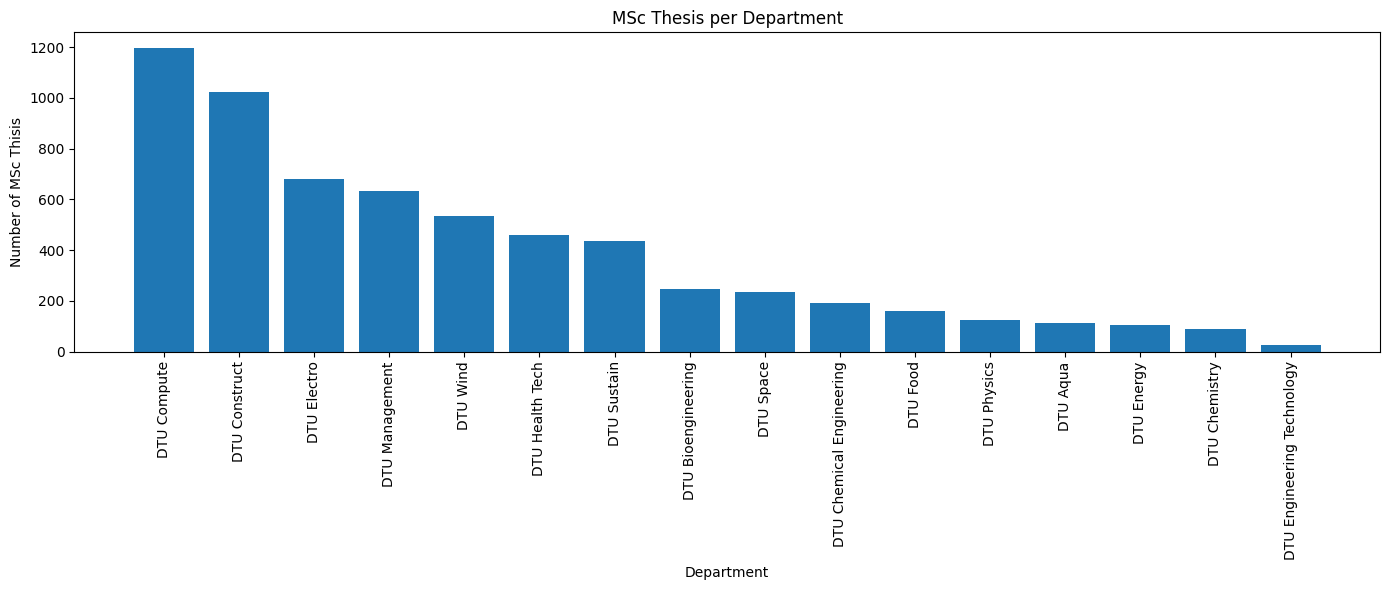

In [5]:
import os
import matplotlib.pyplot as plt

publisher_counts = df_csv["Department_new"].fillna("Missing").value_counts()

plt.figure(figsize=(14, 6))
plt.bar(publisher_counts.index.astype(str), publisher_counts.values)
plt.xlabel("Department")
plt.ylabel("Number of MSc Thisis")
plt.title("MSc Thesis per Department")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()